C:\Users\orvil\AppData\Local\Temp\ipykernel_33096\3651265758.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal_detrend,
C:\Users\orvil\AppData\Local\Temp\ipykernel_33096\3651265758.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal_detrend,


Processed: expt_8_tissue_sample_1.csv
Processed: expt_8_tissue_sample_2.csv
Processed: expt_8_tissue_sample_1_repeat.csv
Processed: expt_8_retry_tissue_sample_1.csv
Processed: expt_8_retry_tissue_sample_2.csv
Processed: expt_8_final_tissue_sample_1.csv
Processed: expt_8_final_tissue_sample_2.csv

============ TISSUE BIREFRINGENCE CLASSIFICATION ============

                         filename  dominant_k_mode  k4_purity_mean  k4_purity_std  malus_r2_mean  malus_r2_std  k4_amp_mean              classification
       expt_8_tissue_sample_1.csv                2          0.1358         0.0390         0.1357        0.0391       2.5301 Non-birefringent (no nerve)
       expt_8_tissue_sample_2.csv                1          0.0530         0.0505         0.0526        0.0503       0.2357 Non-birefringent (no nerve)
expt_8_tissue_sample_1_repeat.csv                1          0.0208         0.0188         0.0207        0.0187       0.1546 Non-birefringent (no nerve)
 expt_8_retry_tissue_sample_1.c

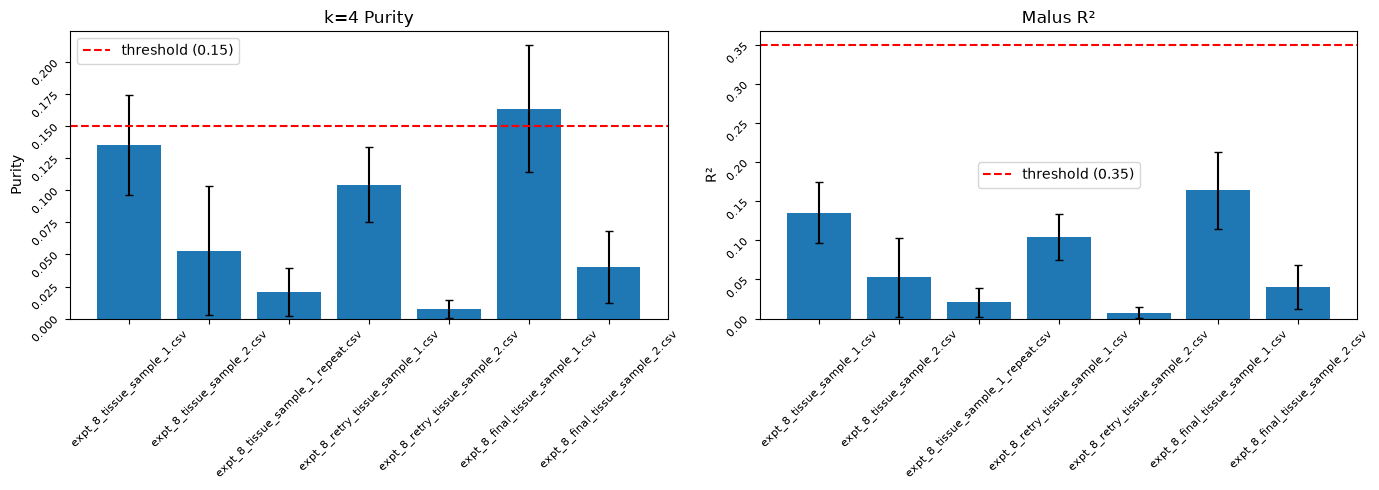


--- Per‑detector details for expt_8_tissue_sample_1.csv ---
  A0: k4 purity=0.131, R²=0.131
  A1: k4 purity=0.065, R²=0.064
  A2: k4 purity=0.131, R²=0.131
  A3: k4 purity=0.180, R²=0.180
  A4: k4 purity=0.127, R²=0.127
  A5: k4 purity=0.181, R²=0.181

--- Per‑detector details for expt_8_tissue_sample_2.csv ---
  A0: k4 purity=0.001, R²=0.001
  A1: k4 purity=0.014, R²=0.014
  A2: k4 purity=0.130, R²=0.130
  A3: k4 purity=0.047, R²=0.047
  A4: k4 purity=0.014, R²=0.014
  A5: k4 purity=0.112, R²=0.111

--- Per‑detector details for expt_8_tissue_sample_1_repeat.csv ---
  A0: k4 purity=0.056, R²=0.056
  A1: k4 purity=0.032, R²=0.032
  A2: k4 purity=0.020, R²=0.020
  A3: k4 purity=0.001, R²=0.001
  A4: k4 purity=0.006, R²=0.006
  A5: k4 purity=0.009, R²=0.009

--- Per‑detector details for expt_8_retry_tissue_sample_1.csv ---
  A0: k4 purity=0.124, R²=0.124
  A1: k4 purity=0.147, R²=0.147
  A2: k4 purity=0.057, R²=0.057
  A3: k4 purity=0.083, R²=0.083
  A4: k4 purity=0.117, R²=0.116
  A5: k

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import detrend
import os
import glob

# ----------------------------------------------------------------------
# 1. Data loading and preprocessing (same as before)
# ----------------------------------------------------------------------
def load_dataset(filename):
    df = pd.read_csv(filename)
    num_points_to_read = df.shape[0] // 30 * 30
    df = df.iloc[:num_points_to_read]
    df.iloc[:, 0] = np.arange(num_points_to_read) * 360 / num_points_to_read
    df.rename(columns={df.columns[0]: "angle"}, inplace=True)
    for col in df.columns:
        if col != "angle":
            df[col] = df[col] - df[col].mean()
            df[col] = df[col].round(2)
    df["total"] = df.drop(columns=["angle"]).sum(axis=1)
    sample_frequency = num_points_to_read / 360
    return df, sample_frequency

# ----------------------------------------------------------------------
# 2. Per‑detector birefringence analysis (same)
# ----------------------------------------------------------------------
def analyze_detector_signal(angles, signal):
    N = len(signal)
    signal_dc = signal - np.mean(signal)
    signal_detrend = detrend(signal_dc)
    
    yf = np.fft.fft(signal_detrend)
    mag = 2.0 / N * np.abs(yf[:N//2])
    power = mag[1:]**2
    total_ac = np.sum(power)
    if total_ac == 0:
        return {"k4_amp": 0, "k4_purity": 0, "malus_r2": 0, "dominant_k": 0}
    
    dom_k = np.argmax(power) + 1
    k4_power = power[3] if len(power) > 3 else 0
    k4_purity = k4_power / total_ac
    k4_amp = mag[4] if len(mag) > 4 else 0
    
    def malus_k4(theta, A, phi, C):
        return A * np.cos(4 * np.radians(theta) + phi) + C
    
    try:
        popt, _ = curve_fit(malus_k4, angles, signal_detrend,
                            p0=[np.std(signal_detrend), 0, 0],
                            maxfev=2000)
        pred = malus_k4(angles, *popt)
        ss_res = np.sum((signal_detrend - pred)**2)
        ss_tot = np.sum((signal_detrend)**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        r2 = max(0, r2)
    except:
        r2 = 0
    
    return {
        "k4_amp": k4_amp,
        "k4_purity": k4_purity,
        "malus_r2": r2,
        "dominant_k": dom_k,
    }

def analyze_tissue_file(filename, signal_col="total"):
    """
    Process a single tissue data file and return averaged metrics over detectors.
    """
    df, _ = load_dataset(filename)
    angles = df["angle"].values
    detector_cols = [c for c in df.columns if c not in ["angle", "total"]]
    results = []
    for col in detector_cols:
        sig = df[col].values
        res = analyze_detector_signal(angles, sig)
        res["detector"] = col
        results.append(res)
    
    avg = {
        "filename": os.path.basename(filename),
        "k4_purity_mean": np.mean([r["k4_purity"] for r in results]),
        "k4_purity_std": np.std([r["k4_purity"] for r in results]),
        "malus_r2_mean": np.mean([r["malus_r2"] for r in results]),
        "malus_r2_std": np.std([r["malus_r2"] for r in results]),
        "k4_amp_mean": np.mean([r["k4_amp"] for r in results]),
        "dominant_k_mode": pd.Series([r["dominant_k"] for r in results]).mode()[0],
        "per_detector": results,  # keep for detailed inspection
    }
    return avg

# ----------------------------------------------------------------------
# 3. Classification function (thresholds tuned for tissue)
# ----------------------------------------------------------------------
def classify_tissue(metrics, purity_threshold=0.15, r2_threshold=0.35):
    """
    Tissue typically has weaker signals, so lower thresholds.
    Adjust these based on your known tissue controls if available.
    """
    purity = metrics["k4_purity_mean"]
    r2 = metrics["malus_r2_mean"]
    dom_k = metrics["dominant_k_mode"]
    if dom_k == 4 and purity >= purity_threshold and r2 >= r2_threshold:
        return "Birefringent (nerve present)"
    else:
        return "Non-birefringent (no nerve)"

# ----------------------------------------------------------------------
# 4. Batch process all tissue files
# ----------------------------------------------------------------------
# Specify your tissue data folder or list of files
# Example: tissue_files = glob.glob("data/tissue_samples/*.csv")
# Or manually provide a list:
tissue_files = [
    "data/expt_8_tissue_sample_1.csv",
    "data/expt_8_tissue_sample_2.csv",

    "data/expt_8_tissue_sample_1_repeat.csv",


   "data/expt_8_retry_tissue_sample_1.csv",
   "data/expt_8_retry_tissue_sample_2.csv",

   "data/expt_8_final_tissue_sample_1.csv",
   "data/expt_8_final_tissue_sample_2.csv" 
]

# If you have a folder with all tissue measurements:
# tissue_files = glob.glob("path/to/tissue_data/*.csv")

if not tissue_files:
    print("No tissue files found. Please update the 'tissue_files' list.")
    exit()

tissue_results = []
for fname in tissue_files:
    try:
        met = analyze_tissue_file(fname)
        met["classification"] = classify_tissue(met)
        tissue_results.append(met)
        print(f"Processed: {met['filename']}")
    except Exception as e:
        print(f"Error processing {fname}: {e}")

# ----------------------------------------------------------------------
# 5. Summary table and visualization
# ----------------------------------------------------------------------
if tissue_results:
    df_tissue = pd.DataFrame(tissue_results)
    # Keep only summary columns for display
    display_cols = ["filename", "dominant_k_mode", "k4_purity_mean", 
                    "k4_purity_std", "malus_r2_mean", "malus_r2_std", 
                    "k4_amp_mean", "classification"]
    summary = df_tissue[display_cols].copy()
    summary = summary.round(4)
    
    print("\n============ TISSUE BIREFRINGENCE CLASSIFICATION ============\n")
    print(summary.to_string(index=False))
    
    # Plot metrics for visual comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # k4 purity
    axes[0].bar(summary["filename"], summary["k4_purity_mean"], 
                yerr=summary["k4_purity_std"], capsize=3)
    axes[0].axhline(y=0.15, color='r', linestyle='--', label='threshold (0.15)')
    axes[0].set_title("k=4 Purity")
    axes[0].set_ylabel("Purity")
    axes[0].tick_params(rotation=45, labelsize=8)
    axes[0].legend()
    
    # Malus R²
    axes[1].bar(summary["filename"], summary["malus_r2_mean"], 
                yerr=summary["malus_r2_std"], capsize=3)
    axes[1].axhline(y=0.35, color='r', linestyle='--', label='threshold (0.35)')
    axes[1].set_title("Malus R²")
    axes[1].set_ylabel("R²")
    axes[1].tick_params(rotation=45, labelsize=8)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Optionally, print per‑detector details for each file
    for res in tissue_results:
        print(f"\n--- Per‑detector details for {res['filename']} ---")
        for det in res["per_detector"]:
            print(f"  {det['detector']}: k4 purity={det['k4_purity']:.3f}, R²={det['malus_r2']:.3f}")
else:
    print("No tissue results to display.")